# Apple Next-Day Direction Prediction

## Project overview

This project uses Apple (AAPL) stock data from Yahoo Finance to predict whether the next trading day’s closing price will be higher than today’s closing price.

The goal is to build a simple baseline classification model using Logistic Regression and technical indicators derived from historical price and volume data.

### Target definition

- `target = 1` if tomorrow’s closing price is greater than today’s closing price
- `target = 0` otherwise

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## Download data

We download Apple stock data using `yfinance` and save a local CSV copy for reproducibility. The analysis below uses the unadjusted `Close` column for feature engineering, consistent with the current notebook version. [file:405]

In [ ]:
ticker = "AAPL"
start_date = "2010-01-01"

data = yf.download(ticker, start=start_date,auto_adjust=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.columns.name = None
data.index.name = "Date"
data_dir = Path("apple") # replace with own path
data_dir.mkdir(parents=True, exist_ok=True)
data.to_csv(data_dir / "AAPL_raw.csv") # saves from having to load again

[*********************100%***********************]  1 of 1 completed


## Data checks

Before analysis, we confirm the shape, data types, date ordering, and missing values.

In [ ]:
data.head()


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.406479,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.417558,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.315477,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.303802,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.345713,7.570714,7.571429,7.466429,7.510714,447610800


In [ ]:
data.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-22,297.010010,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,294.299988,301.640015,294.179993,297.540009,52010900
2026-06-24,293.079987,293.079987,299.700012,292.940002,295.359985,53081900
2026-06-25,275.149994,275.149994,288.799988,273.750000,287.399994,107013700
2026-06-26,283.779999,283.779999,285.950012,274.209991,275.000000,261693600


In [ ]:
rows, cols = data.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")
print("\nColumn info:")
print(data.dtypes)
print("\nMissing values by column:")
print(data.isna().sum())
print(f"\nSorted by date: {data.index.is_monotonic_increasing}")

Rows: 4145
Columns: 6

Column info:
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

Missing values by column:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Sorted by date: True


In [ ]:
first_date  = data.index.min()
last_date   = data.index.max()
n_records   = len(data)
any_missing = data.isna().any().any()
print('Summary')
print("First date:", first_date)
print("Latest date:", last_date)
print("Number of trading-day records:", n_records)
print("Any missing values:", any_missing)


Summary
First date: 2010-01-04 00:00:00
Latest date: 2026-06-26 00:00:00
Number of trading-day records: 4145
Any missing values: False


## Exploratory data analysis

We calculate daily returns, summarize key variables, and inspect unusual price-move and volume days.

In [ ]:
data["Daily_Return"] = data["Close"].pct_change()
data["Close_minus_Open"] = data["Close"] - data["Open"]

eda_summary = pd.Series({
    "Minimum closing price": data["Close"].min(),
    "Maximum closing price": data["Close"].max(),
    "Average closing price": data["Close"].mean(),
    "Median closing price": data["Close"].median(),
    "Average daily trading volume": data["Volume"].mean(),
    "Average daily return": data["Daily_Return"].mean(),
    "Mean close minus open": data["Close_minus_Open"].mean(),
})

eda_summary

,0
Minimum closing price,6.858929e+00
Maximum closing price,3.152000e+02
Average closing price,8.549448e+01
Median closing price,4.290250e+01
Average daily trading volume,2.140762e+08
Average daily return,1.029321e-03
Mean close minus open,6.221595e-02


In [ ]:
# Absolute daily moves
data["Abs_Daily_Return"] = data["Daily_Return"].abs()

# Top 1% largest absolute returns
threshold_ret = data["Abs_Daily_Return"].quantile(0.99)
big_moves = data[data["Abs_Daily_Return"] >= threshold_ret]

# Top 1% largest volumes
threshold_vol = data["Volume"].quantile(0.99)
big_volume_days = data[data["Volume"] >= threshold_vol]

print("Number of very large move days (top 1%):", len(big_moves))
print("Number of very high volume days (top 1%):", len(big_volume_days))

Number of very large move days (top 1%): 42
Number of very high volume days (top 1%): 42


In [ ]:
big_moves[["Close", "Daily_Return", "Volume"]].head(10)


,Close,Daily_Return,Volume
Date,,,
2010-04-21,9.257857,0.059814,982391200
2010-05-10,9.071071,0.076868,984306400
2012-01-25,15.952143,0.062439,958314000
2012-04-25,21.785713,0.088741,905777600
2012-11-19,20.204643,0.072108,823317600
2012-12-05,19.242500,-0.064357,1044638000
2013-01-24,16.089287,-0.123558,1460852400
2014-01-28,18.089287,-0.079927,1065523200
2014-04-24,20.277500,0.081982,759911600


In [ ]:
big_volume_days[["Close", "Daily_Return", "Volume"]].head(10)

,Close,Daily_Return,Volume
Date,,,
2010-01-25,7.252500,0.026903,1065699600
2010-01-26,7.355000,0.014133,1867110000
2010-01-27,7.424286,0.009420,1722568400
2010-01-28,7.117500,-0.041322,1173502400
2010-01-29,6.859286,-0.036279,1245952400
2010-05-06,8.794643,-0.038048,1285860800
2010-05-07,8.423571,-0.042193,1676018400
2010-05-19,8.869286,-0.015930,1025726800
2010-05-20,8.491429,-0.042603,1282915200


Apple’s closing price in this sample ranges from about 6.86 at the low end to about 315.20 at the high end, showing how much the stock has grown over the period. The average closing price is roughly 85.40, while the median is around 42.88, which suggests that many of the earlier observations are clustered at lower price levels and later years bring much higher prices.

Average daily trading volume is about 214 million shares, indicating very high liquidity and constant investor activity in Apple’s stock. The average daily return is approximately 0.10%, so on a typical trading day the price tends to move slightly upward, though the effect is small at the daily scale.

There are 42 days in the top 1% of absolute daily returns and 42 days in the top 1% of trading volume. This shows that a relatively small number of days experience unusually large price moves and unusually heavy trading, which likely correspond to major events such as earnings announcements.

It is also worth noting that big‑move days are spread fairly evenly across the years, which means large percentage price changes occur throughout the sample rather than being concentrated in one early “high‑risk” period. In contrast, unusually high‑volume days appear only up to early 2014, suggesting that trading activity later became more stable or structurally different, so volatility in recent years is less often accompanied by extreme volume spikes.

# Visualisation

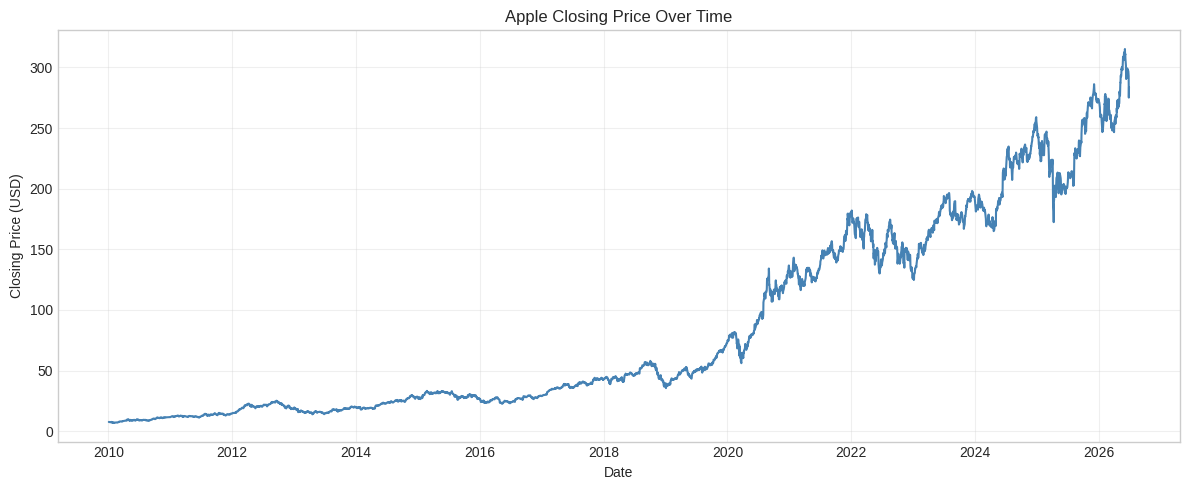

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"], color="steelblue")
plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Apple’s closing price shows a clear long‑term upward trend, rising from single‑digit levels in the early part of the sample to well above 300 USD at its peak. There are several drawdown periods, but the overall direction over 2010–present is strongly positive.

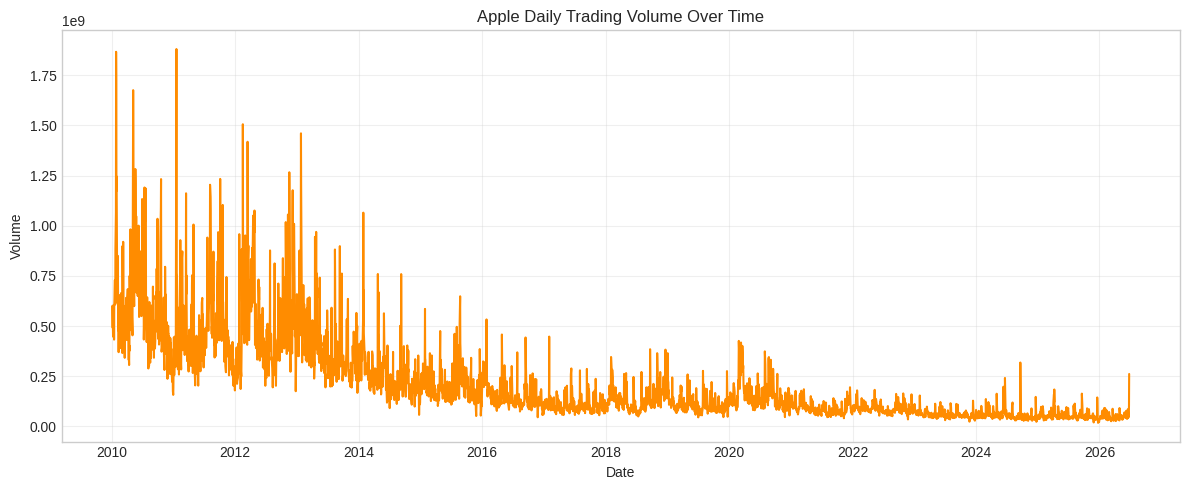

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Volume"], color="darkorange")
plt.title("Apple Daily Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Daily trading volume is consistently high, but the largest volume spikes occur mainly in the earlier years up to around 2015. After that, volume appears more stable, suggesting that extreme bursts of trading activity became less frequent or changed in structure over time.

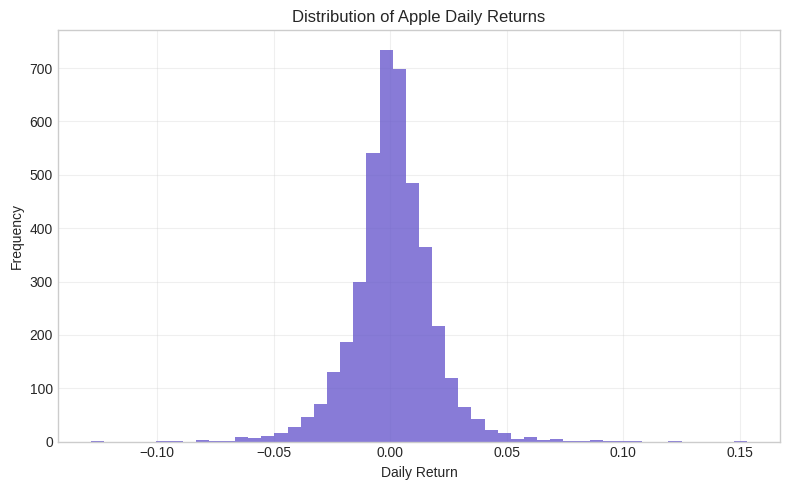

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(data["Daily_Return"].dropna(), bins=50, color="slateblue", alpha=0.8)
plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The distribution of Apple’s daily returns is sharply peaked around zero and decays quickly on both sides, which looks close to a bell‑shaped, approximately normal distribution. There are a few larger positive and negative moves, but extreme return days are relatively rare compared with the large number of small daily changes.

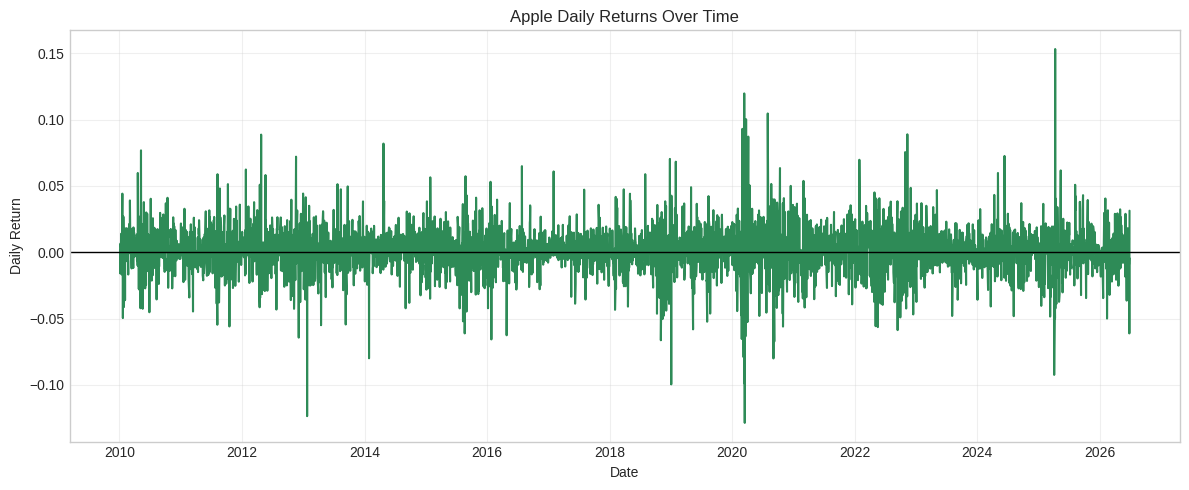

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Daily_Return"], color="seagreen")
plt.title("Apple Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.axhline(0, color="black", linewidth=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The daily‑return series fluctuates around zero with periods where the spikes become much larger, indicating higher volatility. These more volatile episodes correspond to clusters of large positive and negative returns, while calmer periods show smaller, tightly‑grouped movements. Noticeably, there is some high fluctuation around 2020, coinciding with Covid-19.

## Feature engineering

We create return-based, trend-based, volume-based, volatility-based, and momentum-based features from historical data only.

In [ ]:
#Daily, 2-day, 5-day and 10-day returns
data["ret_1d"] = data["Close"].pct_change(1)
data["ret_2d"]  = data["Close"].pct_change(2)
data["ret_5d"]  = data["Close"].pct_change(5)
data["ret_10d"] = data["Close"].pct_change(10)


In [ ]:
# 5-day, 20-day and 50-day moving average
data["ma_5"]  = data["Close"].rolling(window=5).mean()
data["ma_20"] = data["Close"].rolling(window=20).mean()
data["ma_50"] = data["Close"].rolling(window=50).mean()

In [ ]:
# Price‑to‑moving‑average relationships
data["rel_ma_5"]  = (data["Close"] - data["ma_5"])  / data["ma_5"]
data["rel_ma_20"] = (data["Close"] - data["ma_20"]) / data["ma_20"]
data["rel_ma_50"] = (data["Close"] - data["ma_50"]) / data["ma_50"]

In [ ]:
data["vol_change_1d"] = data["Volume"].pct_change(1)

In [ ]:
data["vol_ma_20"]    = data["Volume"].rolling(window=20).mean()
data["rel_vol_20"]   = (data["Volume"] - data["vol_ma_20"]) / data["vol_ma_20"]

In [ ]:
data["vol_5"]  = data["ret_1d"].rolling(window=5).std()
data["vol_10"] = data["ret_1d"].rolling(window=10).std()
data["vol_20"] = data["ret_1d"].rolling(window=20).std()

In [ ]:
window = 14

delta = data["Close"].diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

rs = avg_gain / (avg_loss + 1e-8)
data["RSI_14"] = 100 - (100 / (1 + rs))

## Create the target variable

The target represents next-day direction:

- `1` if tomorrow’s close is higher than today’s close
- `0` otherwise

In [ ]:
# Tomorrow's closing price (shifted up one row)
data["Close_next"] = data["Close"].shift(-1)

# Binary target: 1 if tomorrow's close > today's close, else 0
data["target"] = (data["Close_next"] > data["Close"]).astype(int)

In [ ]:
target_counts = data["target"].value_counts(dropna=True)
print(target_counts)
print("\nClass proportions:\n", target_counts / target_counts.sum())

target
1    2192
0    1953
Name: count, dtype: int64

Class proportions:
 target
1    0.52883
0    0.47117
Name: count, dtype: float64


### Target observations

The target is only mildly imbalanced, with class `1` occurring slightly more often than class `0`. In the current notebook output, class `1` appears 2,192 times and class `0` appears 1,953 times.

## Prepare the modelling dataset

In [ ]:
feature_list = [
    "ret_1d",
    "ret_2d",
    "ret_5d",
    "ret_10d",
    "rel_ma_5",
    "rel_ma_20",
    "rel_ma_50",
    "vol_change_1d",
    "vol_5",
    "vol_10",
    "vol_20",
    "RSI_14",
]

In [ ]:
model_data = data.copy()


model_data[feature_list] = model_data[feature_list].replace([np.inf, -np.inf], np.nan)

model_data = model_data.dropna(subset=feature_list + ["target"])

print("Modelling dataset rows:", len(model_data))

Modelling dataset rows: 4096


In [ ]:
X = model_data[feature_list].values
y = model_data["target"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4096, 12)
y shape: (4096,)


## Chronological train-test split

Because this is time-series data, the rows are not shuffled. The oldest 80% of observations are used for training and the newest 20% for testing. This helps preserve time order and reduces data leakage risk.

In [ ]:
# Ensure chronological order
model_data = model_data.sort_index()

n = len(model_data)
split_idx = int(0.8 * n)

train_data = model_data.iloc[:split_idx]
test_data  = model_data.iloc[split_idx:]

X_train = train_data[feature_list].values
y_train = train_data["target"].values

X_test  = test_data[feature_list].values
y_test  = test_data["target"].values

train_start, train_end = train_data.index.min(), train_data.index.max()
test_start,  test_end  = test_data.index.min(),  test_data.index.max()
dates_train = train_data.index
dates_test  = test_data.index

print("Train period:", train_start, "to", train_end)
print("Test period:", test_start, "to", test_end)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train period: 2010-03-16 00:00:00 to 2023-03-20 00:00:00
Test period: 2023-03-21 00:00:00 to 2026-06-26 00:00:00
Train shape: (3276, 12) Test shape: (820, 12)


In the current notebook output, the training period runs from 2010-03-16 to 2023-03-20 and the testing period runs from 2023-03-21 to 2026-06-26. The train and test shapes are `(3276, 12)` and `(820, 12)` respectively.

## Feature scaling

Logistic Regression is sensitive to feature scale, so the features are standardized using the training data only.

In [ ]:
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Train the Logistic Regression model

In [ ]:
log_reg = LogisticRegression(max_iter=5000, random_state=0,solver='liblinear')

# Train on the scaled training data
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=0, solver='liblinear')

In [ ]:
# Predicted classes (0 or 1)
y_pred = log_reg.predict(X_test_scaled)

# Predicted probability of class 1 (price going up)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

## Build a comparison table

In [ ]:
results = pd.DataFrame({
    "Date": dates_test,
    "Actual": y_test,
    "Predicted": y_pred,
    "Prob_up": y_proba,
})

results["Correct"] = (results["Actual"] == results["Predicted"]).astype(int)
results = results.sort_values("Date")

results.head()

,Date,Actual,Predicted,Prob_up,Correct
0,2023-03-21,0,1,0.545739,0
1,2023-03-22,1,1,0.563438,1
2,2023-03-23,1,1,0.523668,1
3,2023-03-24,0,1,0.533507,0
4,2023-03-27,0,1,0.546495,0


## Evaluate the model

In [ ]:

# Core metrics
acc       = accuracy_score(y_test, y_pred)
bal_acc   = balanced_accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)  # for class 1 by default
rec       = recall_score(y_test, y_pred)     # for class 1 by default
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

cm        = confusion_matrix(y_test, y_pred)
report    = classification_report(y_test, y_pred)

print("Accuracy:", acc)
print("Balanced accuracy:", bal_acc)
print("Precision (class 1):", prec)
print("Recall (class 1):", rec)
print("F1 score:", f1)
print("ROC-AUC:", roc_auc)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

Accuracy: 0.5219512195121951
Balanced accuracy: 0.4938995215311005
Precision (class 1): 0.5331491712707183
Recall (class 1): 0.8772727272727273
F1 score: 0.6632302405498282
ROC-AUC: 0.4582057416267943

Confusion matrix:
 [[ 42 338]
 [ 54 386]]

Classification report:
               precision    recall  f1-score   support

           0       0.44      0.11      0.18       380
           1       0.53      0.88      0.66       440

    accuracy                           0.52       820
   macro avg       0.49      0.49      0.42       820
weighted avg       0.49      0.52      0.44       820



In [ ]:
tn, fp, fn, tp = cm.ravel()

metrics_summary = pd.Series({
    "Accuracy": acc,
    "Balanced accuracy": bal_acc,
    "Precision (class 1)": prec,
    "Recall (class 1)": rec,
    "F1 score": f1,
    "ROC-AUC": roc_auc,
    "True negatives": tn,
    "False positives": fp,
    "False negatives": fn,
    "True positives": tp,
})

metrics_summary

,0
Accuracy,0.521951
Balanced accuracy,0.493900
Precision (class 1),0.533149
Recall (class 1),0.877273
F1 score,0.663230
ROC-AUC,0.458206
True negatives,42.000000
False positives,338.000000
False negatives,54.000000
True positives,386.000000


## Findings

The current Logistic Regression baseline achieves an accuracy of about 0.522, but its balanced accuracy is about 0.494 and its ROC-AUC is about 0.458. This suggests that the model is not learning a strong and reliable signal for separating upward and non-upward days.

The confusion matrix shows that the model correctly identifies many upward days but performs poorly on class `0`. In the current results, it produces 386 true positives but only 42 true negatives, with 338 false positives and 54 false negatives.

This means the model tends to predict “up” too often. That behavior leads to high recall for class `1` but weak overall discrimination, so the model is better interpreted as a simple baseline than as a useful trading strategy.

## Limitations

This project uses only historical price and volume features. It does not include company fundamentals, news, macroeconomic variables, or broader market context, all of which can influence short-term stock movements.

The results also show that next-day direction prediction is difficult. Even with reasonable feature engineering and a clean time-series split, the model’s ROC-AUC remains below 0.5 in the current notebook output, indicating weak ranking performance.

A useful next step would be to compare this model against a majority-class baseline, try a pipeline-based workflow, and test threshold changes or class weighting to study the precision-recall trade-off.

## Conclusion

This notebook demonstrates a complete end-to-end classification workflow for stock-direction prediction: data collection, EDA, feature engineering, target creation, time-aware splitting, scaling, modeling, and evaluation.

The main takeaway is not that Logistic Regression predicts Apple reliably, but that a clean baseline model helps show both the possibilities and the limits of using technical indicators alone for next-day direction prediction.

## Bonus: Hyperparameter tuning

The main part of this notebook builds and evaluates a simple baseline Logistic Regression model using a fixed set of technical indicators and a chronological train–test split.

To see whether careful regularization can improve performance, we now add a short hyperparameter–tuning step. In this section, we:

- Wrap preprocessing and modelling in a single pipeline.
- Use cross‑validation designed for time‑ordered data to avoid training on future information.
- Search over different values of the regularization strength (`C`) and penalty type (`l1`, `l2`).

This extension does not turn the model into a robust trading system, but it shows how to systematically explore model settings and compare a tuned classifier against the original baseline.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [ ]:
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=10000,
        random_state=42,
        solver="liblinear"
    ))
])

In [ ]:
parameter_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "classifier__penalty": ["l1", "l2"],
}

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'classifier__C': 1, 'classifier__penalty': 'l1'}
Best cross-validation accuracy: 0.5113553113553113


In [ ]:
best_pipeline = grid_search.best_estimator_

y_pred_tuned = best_pipeline.predict(X_test)
y_proba_tuned = best_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
acc_tuned = accuracy_score(y_test, y_pred_tuned)
bal_acc_tuned = balanced_accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned)
rec_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

print("Tuned model accuracy:", acc_tuned)
print("Tuned model balanced accuracy:", bal_acc_tuned)
print("Tuned model precision:", prec_tuned)
print("Tuned model recall:", rec_tuned)
print("Tuned model F1 score:", f1_tuned)
print("Tuned model ROC-AUC:", roc_auc_tuned)
print("\nTuned confusion matrix:\n", cm_tuned)
print("\nTuned classification report:\n", report_tuned)

Tuned model accuracy: 0.5231707317073171
Tuned model balanced accuracy: 0.49395933014354065
Tuned model precision: 0.5332428765264586
Tuned model recall: 0.8931818181818182
Tuned model F1 score: 0.6677994902293968
Tuned model ROC-AUC: 0.46044258373205743

Tuned confusion matrix:
 [[ 36 344]
 [ 47 393]]

Tuned classification report:
               precision    recall  f1-score   support

           0       0.43      0.09      0.16       380
           1       0.53      0.89      0.67       440

    accuracy                           0.52       820
   macro avg       0.48      0.49      0.41       820
weighted avg       0.49      0.52      0.43       820



In [ ]:
comparison_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC-AUC"
    ],
    "Baseline": [
        acc,
        bal_acc,
        prec,
        rec,
        f1,
        roc_auc
    ],
    "Tuned": [
        acc_tuned,
        bal_acc_tuned,
        prec_tuned,
        rec_tuned,
        f1_tuned,
        roc_auc_tuned
    ]
})

comparison_metrics

,Metric,Baseline,Tuned
0,Accuracy,0.521951,0.523171
1,Balanced accuracy,0.493900,0.493959
2,Precision,0.533149,0.533243
3,Recall,0.877273,0.893182
4,F1 score,0.663230,0.667799
5,ROC-AUC,0.458206,0.460443


##Discussion
Tuning the Logistic Regression model leads to only very small changes in performance. Accuracy and balanced accuracy barely move, and precision is almost identical. The main change is slightly higher recall and F1 for upward days, meaning the tuned model catches a few more up moves but still behaves much like the baseline. With ROC‑AUC still well below 0.5, the tuned model remains weak at ranking up vs. non‑up days.

##Conclusion
Hyperparameter tuning slightly refines the model but does not make it genuinely strong. The classifier continues to over‑predict upward days and offers only marginal improvement over the original setup. This reinforces the main message of the project: with these features and this horizon, next‑day stock‑direction prediction is hard, and even a carefully tuned model should be viewed as an educational baseline, not a reliable trading tool.